In [181]:
# ============================================================================
# UTILITY FUNCTIONS FOR STYLED TABLE DISPLAY
# ============================================================================
# These functions can be used throughout the notebook to display any dataframe
# with professional styling

from IPython.display import HTML, display

def display_styled_table(df, title=None, header_color="#4CAF50", 
                         font_size="11px", width="100%", 
                         alternate_rows=True, hover_effect=True):
    """
    Display a pandas DataFrame as a styled HTML table.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to display
    title : str, optional
        Title to display above the table
    header_color : str, default "#4CAF50"
        Background color for header (hex or color name)
        Examples: "#4CAF50" (green), "#2196F3" (blue), "#FF9800" (orange)
    font_size : str, default "11px"
        Font size for table content
    width : str, default "100%"
        Table width
    alternate_rows : bool, default True
        Whether to alternate row colors
    hover_effect : bool, default True
        Whether to add hover highlighting effect
    
    Returns:
    --------
    None (displays the table)
    
    Examples:
    ---------
    # Basic usage
    display_styled_table(df)
    
    # With title and custom colors
    display_styled_table(df, title="Sales Data", header_color="#2196F3")
    
    # Without hover effect
    display_styled_table(df, hover_effect=False)
    """
    
    # Print title if provided
    if title:
        print("\n" + "=" * 120)
        print(title)
        print("=" * 120)
    
    # Create HTML table
    html_table = df.to_html(index=False, border=1, justify='center')
    
    # Build CSS styles
    css_styles = f"""
    <style>
        table {{
            border-collapse: collapse;
            width: {width};
            font-size: {font_size};
        }}
        th {{
            background-color: {header_color};
            color: white;
            padding: 8px;
            text-align: center;
            font-weight: bold;
        }}
        td {{
            padding: 6px;
            text-align: center;
            border: 1px solid #ddd;
        }}
    """
    
    # Add alternate row colors if enabled
    if alternate_rows:
        css_styles += """
        tr:nth-child(even) {
            background-color: #f2f2f2;
        }
        """
    
    # Add hover effect if enabled
    if hover_effect:
        css_styles += """
        tr:hover {
            background-color: #ddd;
        }
        """
    
    css_styles += """
    </style>
    """
    
    # Combine styles and table
    html_styled = css_styles + html_table
    
    # Display
    display(HTML(html_styled))


def display_table_with_stats(df, title=None, stats_cols=None, **kwargs):
    """
    Display a styled table with summary statistics below it.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to display
    title : str, optional
        Title to display above the table
    stats_cols : list, optional
        Column names to calculate statistics for (numeric columns only)
        If None, calculates for all numeric columns
    **kwargs : dict
        Additional arguments passed to display_styled_table()
    
    Returns:
    --------
    None (displays the table and statistics)
    
    Examples:
    ---------
    # Display table with statistics for all numeric columns
    display_table_with_stats(df, title="Sales Summary")
    
    # Display table with statistics for specific columns
    display_table_with_stats(df, title="Sales Summary", stats_cols=['AIC', 'Improvement'])
    """
    
    # Display the main table
    display_styled_table(df, title=title, **kwargs)
    
    # Calculate and display statistics
    if stats_cols is None:
        # Use all numeric columns
        stats_cols = df.select_dtypes(include=['number']).columns.tolist()
    
    if stats_cols:
        print("\n" + "-" * 80)
        print("SUMMARY STATISTICS")
        print("-" * 80)
        
        stats_df = df[stats_cols].describe().round(4)
        display_styled_table(stats_df, header_color="#2196F3", font_size="10px")


# Predefined color schemes for easy use
TABLE_COLORS = {
    'green': '#4CAF50',
    'blue': '#2196F3',
    'orange': '#FF9800',
    'red': '#F44336',
    'purple': '#9C27B0',
    'teal': '#009688',
    'indigo': '#3F51B5',
    'cyan': '#00BCD4',
    'lime': '#8BC34A',
    'pink': '#E91E63',
}

print("✅ Styled table display functions loaded!")
print("   Available functions:")
print("   • display_styled_table(df, title, header_color, ...)")
print("   • display_table_with_stats(df, title, stats_cols, ...)")
print("   • TABLE_COLORS: Predefined color schemes")


✅ Styled table display functions loaded!
   Available functions:
   • display_styled_table(df, title, header_color, ...)
   • display_table_with_stats(df, title, stats_cols, ...)
   • TABLE_COLORS: Predefined color schemes


In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from scipy.stats import norm
from scipy import stats
from pathlib import Path
from IPython.display import display, HTML
import sys
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Display with better formatting - all columns visible
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [183]:
# Gets the parent directory of the current working directory
project_root = Path.cwd().parent.parent
fullpath = "{}/data/VST152/pva_donors.csv".format(project_root)
donor_data = pd.read_csv(fullpath)
donor_data = donor_data.drop(columns=['Rep_DemMedIncome','IM_Rep_DemMedIncome','log_GiftCnt36'])
print(f"Data loaded successfully!")
print(f"Shape: {donor_data.shape}")
donor_data.head()

Data loaded successfully!
Shape: (9686, 28)


,ID,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome,Response,Donation_Amt
0,14974,2.0,4.0,1.0,3.0,17.0,13.50,9.25,17.00,21.0,66.0,8.0,17.0,26.0,3.0,8.0,13.0,A,0.0,0,NaN,F,U,0.0,0.0,0.0,No,NaN
1,6294,1.0,8.0,0.0,3.0,20.0,20.00,15.88,NaN,26.0,92.0,14.0,35.0,79.0,5.0,5.0,24.0,A,0.0,23,67.0,F,U,186800.0,85.0,0.0,No,NaN
2,46110,6.0,41.0,3.0,20.0,6.0,5.17,3.73,5.00,18.0,111.0,12.0,23.0,51.0,5.0,11.0,22.0,S,1.0,0,NaN,M,U,87600.0,36.0,38750.0,Yes,55.451774
3,185937,3.0,12.0,3.0,8.0,10.0,8.67,8.50,8.67,9.0,93.0,14.0,22.0,44.0,2.0,6.0,16.0,E,1.0,0,NaN,M,U,139200.0,27.0,38942.0,Yes,92.103404
4,29637,1.0,1.0,1.0,1.0,20.0,20.00,20.00,20.00,21.0,21.0,10.0,15.0,13.0,4.0,7.0,6.0,F,0.0,35,53.0,M,U,168100.0,37.0,71509.0,No,NaN


# Multiple Regression Analysis with Stepwise Selection

## Overview
This analysis demonstrates **multiple linear regression** with **stepwise variable selection using AIC (Akaike Information Criterion)**. 

### Why Multiple Regression?
- **Simple regression** uses one predictor; **multiple regression** uses multiple predictors
- Helps us understand how multiple factors jointly influence the target variable (Donation_Amt)
- More realistic as real-world outcomes depend on multiple factors

### Why Stepwise Selection with AIC?
- **Stepwise selection** automatically selects the best subset of variables
- **AIC** balances model fit with complexity (penalizes adding unnecessary variables)
- Prevents overfitting and improves model generalization
- More efficient than manually testing all combinations

### Workflow:
1. **Data Preparation**: Clean data, handle missing values, encode categorical variables
2. **Exploratory Analysis**: Understand data structure and distributions
3. **Model Building**: Use stepwise selection to find optimal variables
4. **Model Evaluation**: Assess fit quality and assumptions
5. **Diagnostics**: Check for violations of regression assumptions

## Step 1: Data Preparation & Cleaning

### What we're doing:
- Filtering to only observations with donation amounts (our target variable)
- Removing ID column (not a predictor)
- Identifying and encoding categorical variables
- **Handling numeric columns that represent categories** (like DemCluster, StatusCatStarAll)
- Handling missing values

### Why it matters:
- Regression requires complete cases (no missing values in predictors)
- Categorical variables must be encoded as numeric (dummy variables)
- Some columns are stored as numbers but represent categories (e.g., cluster IDs, flags)
- Clean data ensures reliable model results

### Important Note on Numeric Categorical Columns:

**DemCluster** (values: 00-53)
- Represents demographic cluster assignments
- Even though stored as `int64`, these are categorical identifiers, not numeric values
- Treating as numeric would imply cluster 40 = 2 × cluster 20, which is wrong

**StatusCatStarAll** (values: 0, 1)
- Binary flag indicating star status (0 = No, 1 = Yes)
- Even though stored as `float64`, this is a categorical indicator, not a numeric measurement
- Treating as numeric would imply status 1 is "twice" status 0, which is wrong

Both must be explicitly converted to categorical for proper encoding.

In [184]:
# Step 1: Data Preparation
# Filter to only records with donation amounts (our dependent variable)
df_analysis = donor_data[donor_data['Donation_Amt'].notna()].copy()

# Remove ID column (not a predictor)
df_analysis = df_analysis.drop('ID', axis=1)

print("=" * 80)
print("INITIAL DATA ASSESSMENT")
print("=" * 80)
print(f"\nOriginal dataset shape: {donor_data.shape}")
print(f"Dataset with donations shape: {df_analysis.shape}")
print(f"Records removed (no donation): {donor_data.shape[0] - df_analysis.shape[0]}")

# Identify categorical and numeric columns
categorical_cols = df_analysis.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_analysis.select_dtypes(include=['int64', 'float64']).columns.tolist()

# IMPORTANT: Add numeric columns that represent categories
# These columns are stored as numbers but represent categorical identifiers
numeric_categorical = ['DemCluster', 'StatusCatStarAll']

for col in numeric_categorical:
    if col in numeric_cols:
        categorical_cols.append(col)
        numeric_cols.remove(col)
        print(f"\n⚠️  NOTE: {col} moved to categorical (categorical identifier, not numeric measurement)")

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_info = pd.DataFrame({
    'Column': df_analysis.columns,
    'Missing_Count': df_analysis.isnull().sum(),
    'Missing_Percent': (df_analysis.isnull().sum() / len(df_analysis) * 100).round(2)
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_info.to_string(index=False))

INITIAL DATA ASSESSMENT

Original dataset shape: (9686, 28)
Dataset with donations shape: (4843, 27)
Records removed (no donation): 4843

⚠️  NOTE: DemCluster moved to categorical (categorical identifier, not numeric measurement)

⚠️  NOTE: StatusCatStarAll moved to categorical (categorical identifier, not numeric measurement)

Categorical columns (6): ['StatusCat96NK', 'DemGender', 'DemHomeOwner', 'Response', 'DemCluster', 'StatusCatStarAll']
Numeric columns (21): ['GiftCnt36', 'GiftCntAll', 'GiftCntCard36', 'GiftCntCardAll', 'GiftAvgLast', 'GiftAvg36', 'GiftAvgAll', 'GiftAvgCard36', 'GiftTimeLast', 'GiftTimeFirst', 'PromCnt12', 'PromCnt36', 'PromCntAll', 'PromCntCard12', 'PromCntCard36', 'PromCntCardAll', 'DemAge', 'DemMedHomeValue', 'DemPctVeterans', 'DemMedIncome', 'Donation_Amt']

MISSING VALUES ANALYSIS
       Column  Missing_Count  Missing_Percent
       DemAge           1164            24.03
GiftAvgCard36            732            15.11


### Why DemCluster and StatusCatStarAll Failed to Auto-Recognize as Categorical

**The Problem:**
- DemCluster is stored as `int64` (numeric data type) in the CSV file
- StatusCatStarAll is stored as `float64` (numeric data type) in the CSV file
- Pandas automatically reads numeric-looking columns as numbers
- Our auto-detection only looked for `object` dtype (strings)
- Result: Both were treated as numeric instead of categorical

**The Solution:**
- Explicitly identify columns that are numeric but represent categories
- Move them from numeric_cols to categorical_cols
- This ensures they get one-hot encoded like other categorical variables

**How to Identify Such Columns:**
1. Check if the column has a small number of unique values (< 50)
2. Values represent categories/groups, not measurements
3. Arithmetic operations don't make sense (e.g., cluster 40 ÷ 2 ≠ cluster 20)
4. Examples: Cluster IDs, Codes, Flags, Regions, Zones, Binary indicators

**Alternative Approaches:**
- Specify dtype when reading CSV: `pd.read_csv(..., dtype={'DemCluster': 'str', 'StatusCatStarAll': 'str'})`
- Convert after loading: `df['DemCluster'] = df['DemCluster'].astype('str')`
- Use categorical dtype: `df['DemCluster'] = df['DemCluster'].astype('category')`
- Manual list (what we implemented): Check if column in numeric_cols, then move to categorical_cols

In [185]:
# Handle missing values and prepare data for regression
# Strategy: Remove rows with missing values in key predictors
df_clean = df_analysis.dropna()

print("\n" + "=" * 80)
print("DATA CLEANING RESULTS")
print("=" * 80)
print(f"Records after removing missing values: {len(df_clean)}")
print(f"Records removed: {len(df_analysis) - len(df_clean)}")
print(f"Retention rate: {(len(df_clean) / len(df_analysis) * 100):.2f}%")

# Encode categorical variables using one-hot encoding
# This converts categorical variables into dummy variables (0/1)
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"\nShape after encoding categorical variables: {df_encoded.shape}")
print(f"New columns created from categorical encoding: {df_encoded.shape[1] - df_clean.shape[1]}")

# Display the encoded columns
print("\nEncoded categorical variables:")
for col in categorical_cols:
    encoded_cols = [c for c in df_encoded.columns if c.startswith(col + '_')]
    print(f"  {col}: {encoded_cols}")


DATA CLEANING RESULTS
Records after removing missing values: 3101
Records removed: 1742
Retention rate: 64.03%

Shape after encoding categorical variables: (3101, 83)
New columns created from categorical encoding: 56

Encoded categorical variables:
  StatusCat96NK: ['StatusCat96NK_E', 'StatusCat96NK_F', 'StatusCat96NK_L', 'StatusCat96NK_N', 'StatusCat96NK_S']
  DemGender: ['DemGender_M', 'DemGender_U']
  DemHomeOwner: ['DemHomeOwner_U']
  Response: []
  DemCluster: ['DemCluster_1', 'DemCluster_2', 'DemCluster_3', 'DemCluster_4', 'DemCluster_5', 'DemCluster_6', 'DemCluster_7', 'DemCluster_8', 'DemCluster_9', 'DemCluster_10', 'DemCluster_11', 'DemCluster_12', 'DemCluster_13', 'DemCluster_14', 'DemCluster_15', 'DemCluster_16', 'DemCluster_17', 'DemCluster_18', 'DemCluster_19', 'DemCluster_20', 'DemCluster_21', 'DemCluster_22', 'DemCluster_23', 'DemCluster_24', 'DemCluster_25', 'DemCluster_26', 'DemCluster_27', 'DemCluster_28', 'DemCluster_29', 'DemCluster_30', 'DemCluster_31', 'DemCluste

## Step 2: Observations Summary

### Table 1: Number of Observations Read and Used

This table shows:
- **Observations Read**: Total records in the dataset
- **Observations Used**: Records actually used in the analysis (after removing missing values)

This is important because it tells us how much data we lost due to missing values and whether our sample size is adequate for reliable regression results.

In [186]:
# TABLE 1: Number of Observations Read and Used
print("\n" + "=" * 80)
print("TABLE 1: NUMBER OF OBSERVATIONS READ AND USED")
print("=" * 80)

obs_summary = pd.DataFrame({
    'Metric': ['Observations Read', 'Observations Used', 'Observations Excluded'],
    'Count': [len(donor_data), len(df_encoded), len(donor_data) - len(df_encoded)]
})

print(obs_summary.to_string(index=False))
print("\nNote: Observations excluded due to missing values in key variables")


TABLE 1: NUMBER OF OBSERVATIONS READ AND USED
               Metric  Count
    Observations Read   9686
    Observations Used   3101
Observations Excluded   6585

Note: Observations excluded due to missing values in key variables


## Step 3: Class Levels and Values

### Table 2: Class Variables, Levels, and Values

This table shows all categorical variables and their encoded levels:
- **Class**: The original categorical variable name
- **Levels**: Number of unique categories
- **Values**: The actual category values

### Why this matters:
- Helps us understand what categories exist in our data
- Shows how many dummy variables were created for each categorical variable
- Important for interpreting model coefficients later

In [187]:
# TABLE 2: Class Variables, Levels, and Values
print("\n" + "=" * 80)
print("TABLE 2: CLASS VARIABLES, LEVELS, AND VALUES")
print("=" * 80)

class_info = []
for col in categorical_cols:
    unique_vals = df_clean[col].unique()
    class_info.append({
        'Class': col,
        'Levels': len(unique_vals),
        'Values': ', '.join(str(v) for v in sorted(unique_vals))
    })

class_df = pd.DataFrame(class_info)
print(class_df.to_string(index=False))

print("\n" + "=" * 80)
print("ENCODING DETAILS")
print("=" * 80)
print("Note: Categorical variables are encoded using one-hot encoding (dummy variables)")
print("The first category of each variable is dropped to avoid multicollinearity")
print("This is called the 'reference category' or 'baseline' category")
print("\nExample: If DemGender has values [F, M, U]:")
print("  - F becomes the reference (baseline)")
print("  - M is encoded as DemGender_M (1 if M, 0 otherwise)")
print("  - U is encoded as DemGender_U (1 if U, 0 otherwise)")


TABLE 2: CLASS VARIABLES, LEVELS, AND VALUES
           Class  Levels                                                                                                                                                                                                       Values
   StatusCat96NK       6                                                                                                                                                                                             A, E, F, L, N, S
       DemGender       3                                                                                                                                                                                                      F, M, U
    DemHomeOwner       2                                                                                                                                                                                                         H, U
        Response       1          

## Step 4: Model Dimensions

### Table 3: Dimensions

This table shows the structure of our regression model:
- **Number of Effects**: Total number of predictor variables (including encoded categorical variables)
- **Number of Parameters**: Number of coefficients to estimate (includes intercept)

### Why this matters:
- Helps us understand model complexity
- More parameters = more complex model = higher risk of overfitting
- We need enough observations relative to parameters (rule of thumb: 10-20 observations per parameter)

In [188]:
# Prepare data for regression
# Separate dependent variable (y) and independent variables (X)
y = df_encoded['Donation_Amt'].astype(float)
X = df_encoded.drop('Donation_Amt', axis=1).astype(float)

# TABLE 3: Model Dimensions
print("\n" + "=" * 80)
print("TABLE 3: MODEL DIMENSIONS")
print("=" * 80)

dimensions = pd.DataFrame({
    'Dimension': ['Number of Effects', 'Number of Parameters', 'Observations Used'],
    'Value': [X.shape[1], X.shape[1] + 1, len(df_encoded)]  # +1 for intercept
})

print(dimensions.to_string(index=False))

print("\nInterpretation:")
print(f"  - We have {X.shape[1]} predictor variables")
print(f"  - We will estimate {X.shape[1] + 1} parameters (including intercept)")
print(f"  - Ratio of observations to parameters: {len(df_encoded) / (X.shape[1] + 1):.1f}:1")
print(f"  - This ratio is {'GOOD' if len(df_encoded) / (X.shape[1] + 1) >= 10 else 'MARGINAL'} (should be >= 10:1)")

print("\nPredictor variables:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")


TABLE 3: MODEL DIMENSIONS
           Dimension  Value
   Number of Effects     82
Number of Parameters     83
   Observations Used   3101

Interpretation:
  - We have 82 predictor variables
  - We will estimate 83 parameters (including intercept)
  - Ratio of observations to parameters: 37.4:1
  - This ratio is GOOD (should be >= 10:1)

Predictor variables:
  1. GiftCnt36
  2. GiftCntAll
  3. GiftCntCard36
  4. GiftCntCardAll
  5. GiftAvgLast
  6. GiftAvg36
  7. GiftAvgAll
  8. GiftAvgCard36
  9. GiftTimeLast
  10. GiftTimeFirst
  11. PromCnt12
  12. PromCnt36
  13. PromCntAll
  14. PromCntCard12
  15. PromCntCard36
  16. PromCntCardAll
  17. DemAge
  18. DemMedHomeValue
  19. DemPctVeterans
  20. DemMedIncome
  21. StatusCat96NK_E
  22. StatusCat96NK_F
  23. StatusCat96NK_L
  24. StatusCat96NK_N
  25. StatusCat96NK_S
  26. DemGender_M
  27. DemGender_U
  28. DemHomeOwner_U
  29. DemCluster_1
  30. DemCluster_2
  31. DemCluster_3
  32. DemCluster_4
  33. DemCluster_5
  34. DemCluster_

## Step 5: Stepwise Variable Selection with AIC

### What is Stepwise Selection?

**Stepwise selection** is an automated procedure that builds a regression model by:
1. **Forward Selection**: Starting with no variables, adding variables one at a time
2. **Backward Elimination**: Starting with all variables, removing variables one at a time
3. **Bidirectional**: Combining both approaches

### Why AIC (Akaike Information Criterion)?

**AIC** is a measure that balances:
- **Model Fit**: How well the model explains the data (lower residual sum of squares is better)
- **Model Complexity**: Number of parameters (fewer parameters is better)

Formula: `AIC = 2k + n*ln(RSS/n)` where k = number of parameters, n = observations, RSS = residual sum of squares

**Lower AIC = Better Model**

### Advantages of Stepwise Selection:
- Automatically finds a good subset of variables
- Reduces multicollinearity by removing correlated variables
- Improves model interpretability (fewer variables)
- Prevents overfitting

### Limitations:
- May not find the globally optimal model
- Can be unstable with highly correlated variables
- Should be combined with domain knowledge

### Alternatives:
- **Best Subset Selection**: Tests all possible combinations (computationally expensive)
- **Ridge/Lasso Regression**: Shrinkage methods that penalize large coefficients
- **Manual Selection**: Based on domain expertise and statistical significance

In [189]:
# Implement Stepwise Selection using AIC
# We'll use a forward selection approach with AIC criterion

def forward_selection_aic(X, y, verbose=True):
    """
    Perform forward stepwise selection using AIC criterion.
    
    Parameters:
    -----------
    X : DataFrame
        Independent variables
    y : Series
        Dependent variable
    verbose : bool
        Print detailed information
    
    Returns:
    --------
    selected_features : list
        List of selected features
    selection_history : list
        History of selection steps
    """
    
    # Initialize
    selected_features = []
    remaining_features = list(X.columns)
    selection_history = []
    
    # Calculate AIC for null model (intercept only)
    null_X = pd.DataFrame({'const': np.ones(len(y), dtype=float)}, index=y.index)
    null_model = sm.OLS(y, null_X).fit()
    null_aic = null_model.aic
    
    if verbose:
        print("\n" + "=" * 80)
        print("TABLE 4: STEPWISE SELECTION SUMMARY (FORWARD SELECTION)")
        print("=" * 80)
        print(f"\nNull Model AIC (intercept only): {null_aic:.4f}\n")
    
    step = 0
    
    # Forward selection loop
    while len(remaining_features) > 0:
        step += 1
        best_feature = None
        best_aic = float('inf')
        best_model = None
        
        # Try adding each remaining feature
        for feature in remaining_features:
            test_features = selected_features + [feature]
            X_test = X[test_features]
            X_test = sm.add_constant(X_test)
            
            model = sm.OLS(y, X_test).fit()
            
            if model.aic < best_aic:
                best_aic = model.aic
                best_feature = feature
                best_model = model
        
        # Check if adding the best feature improves the model
        if len(selected_features) == 0:
            current_aic = null_aic
        else:
            X_current = X[selected_features]
            X_current = sm.add_constant(X_current)
            current_model = sm.OLS(y, X_current).fit()
            current_aic = current_model.aic
        
        # Add feature if it improves AIC (or if it's the first feature)
        if best_aic < current_aic or len(selected_features) == 0:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            
            selection_history.append({
                'Step': step,
                'Effect_Entered': best_feature,
                'Effect_Removed': '',
                'Num_Effects_In': len(selected_features),
                'Num_Params_In': len(selected_features) + 1,
                'AIC': best_aic
            })
            
            if verbose:
                print(f"Step {step}: Added '{best_feature}'")
                print(f"  Number of effects in model: {len(selected_features)}")
                print(f"  Number of parameters: {len(selected_features) + 1}")
                print(f"  AIC: {best_aic:.4f}")
                print(f"  AIC improvement: {current_aic - best_aic:.4f}\n")
        else:
            # Stop if no improvement
            if verbose:
                print(f"\nStopping: No improvement in AIC by adding remaining features")
            break
    
    return selected_features, selection_history

# Run forward selection
selected_features, selection_history = forward_selection_aic(X, y, verbose=True)

# Display selection history as table
selection_df = pd.DataFrame(selection_history)
print("\n" + "=" * 80)
print("STEPWISE SELECTION SUMMARY TABLE")
print("=" * 80)
# Display selection history as table
selection_df = pd.DataFrame(selection_history)
print("\n" + "=" * 120)
print("STEPWISE SELECTION SUMMARY TABLE")
print("=" * 120)

# Display with full width and no truncation
with pd.option_context('display.max_columns', None, 
                       'display.max_rows', None,
                       'display.width', None,
                       'display.max_colwidth', None):
    print(selection_df.to_string(index=False))




TABLE 4: STEPWISE SELECTION SUMMARY (FORWARD SELECTION)

Null Model AIC (intercept only): 28918.1925

Step 1: Added 'GiftAvg36'
  Number of effects in model: 1
  Number of parameters: 2
  AIC: 27070.3967
  AIC improvement: 1847.7958

Step 2: Added 'GiftCnt36'
  Number of effects in model: 2
  Number of parameters: 3
  AIC: 26831.4285
  AIC improvement: 238.9682

Step 3: Added 'GiftAvgLast'
  Number of effects in model: 3
  Number of parameters: 4
  AIC: 26736.4884
  AIC improvement: 94.9401

Step 4: Added 'PromCntCard12'
  Number of effects in model: 4
  Number of parameters: 5
  AIC: 26674.3011
  AIC improvement: 62.1873

Step 5: Added 'GiftTimeFirst'
  Number of effects in model: 5
  Number of parameters: 6
  AIC: 26626.2906
  AIC improvement: 48.0105

Step 6: Added 'PromCntCard36'
  Number of effects in model: 6
  Number of parameters: 7
  AIC: 26585.4591
  AIC improvement: 40.8315

Step 7: Added 'GiftAvgAll'
  Number of effects in model: 7
  Number of parameters: 8
  AIC: 26568.67

In [190]:
# Display as HTML table using the reusable function
display_styled_table(
    selection_df, 
    title="STEPWISE SELECTION SUMMARY - HTML TABLE FORMAT",
    header_color=TABLE_COLORS['green'],
    font_size="11px"
)


STEPWISE SELECTION SUMMARY - HTML TABLE FORMAT


Step,Effect_Entered,Effect_Removed,Num_Effects_In,Num_Params_In,AIC
1,GiftAvg36,,1,2,27070.396716
2,GiftCnt36,,2,3,26831.428493
3,GiftAvgLast,,3,4,26736.488403
4,PromCntCard12,,4,5,26674.301118
5,GiftTimeFirst,,5,6,26626.290604
6,PromCntCard36,,6,7,26585.459105
7,GiftAvgAll,,7,8,26568.678595
8,StatusCat96NK_S,,8,9,26556.536040
9,StatusCat96NK_E,,9,10,26548.942868
10,GiftTimeLast,,10,11,26538.305621


In [191]:
print("\n" + "=" * 120)
print("INTERPRETATION")
print("=" * 120)
print(f"Total steps: {len(selection_history)}")
print(f"Final model AIC: {selection_history[-1]['AIC']:.4f}")
print(f"Total AIC improvement: {selection_history[0]['AIC'] - selection_history[-1]['AIC']:.4f}")
print(f"Average AIC improvement per step: {(selection_history[0]['AIC'] - selection_history[-1]['AIC']) / len(selection_history):.4f}")
print(f"\nLargest improvement: Step 1 ({selection_history[0]['AIC'] - selection_history[1]['AIC']:.4f})")
print(f"Smallest improvement: Step {len(selection_history)} ({selection_history[-2]['AIC'] - selection_history[-1]['AIC']:.4f})")


INTERPRETATION
Total steps: 24
Final model AIC: 26516.0269
Total AIC improvement: 554.3698
Average AIC improvement per step: 23.0987

Largest improvement: Step 1 (238.9682)
Smallest improvement: Step 24 (0.4483)


## Step 6: Stepwise Selection Stop Details

### Table 5: Stop Details

This table shows the final step of the selection process:
- **Candidate For**: What action was being considered (Entry/Removal)
- **Effect**: The variable being considered
- **Candidate AIC**: AIC if the variable was added/removed
- **Compare AIC**: Current model AIC for comparison

### Why this matters:
- Shows why the selection process stopped
- Indicates which variables were considered but not added
- Helps understand the trade-off between model fit and complexity

In [192]:
# TABLE 5: Stop Details - Show candidates that were NOT selected
print("\n" + "=" * 80)
print("TABLE 5: STOP DETAILS - CANDIDATES NOT SELECTED")
print("=" * 80)

# Get current model AIC
X_selected = X[selected_features]
X_selected = sm.add_constant(X_selected)
final_model = sm.OLS(y, X_selected).fit()
current_aic = final_model.aic

# Check remaining features
remaining_features = [f for f in X.columns if f not in selected_features]
stop_details = []

for feature in remaining_features[:10]:  # Show top 10 candidates
    X_test = X[selected_features + [feature]]
    X_test = sm.add_constant(X_test)
    test_model = sm.OLS(y, X_test).fit()
    
    stop_details.append({
        'Candidate_For': 'Entry',
        'Effect': feature,
        'Candidate_AIC': test_model.aic,
        'Compare_AIC': current_aic,
        'AIC_Difference': test_model.aic - current_aic
    })

stop_df = pd.DataFrame(stop_details).sort_values('AIC_Difference')
print(stop_df.to_string(index=False))

print("\nInterpretation:")
print("- Positive AIC_Difference: Adding this variable would INCREASE AIC (worse model)")
print("- Negative AIC_Difference: Adding this variable would DECREASE AIC (better model)")
print("- Selection stopped because all remaining variables have positive AIC_Difference")


TABLE 5: STOP DETAILS - CANDIDATES NOT SELECTED
Candidate_For          Effect  Candidate_AIC  Compare_AIC  AIC_Difference
        Entry DemMedHomeValue   26516.302728 26516.026937        0.275791
        Entry   GiftCntCard36   26516.325564 26516.026937        0.298627
        Entry          DemAge   26516.602517 26516.026937        0.575580
        Entry       PromCnt36   26517.149481 26516.026937        1.122544
        Entry      GiftCntAll   26517.157616 26516.026937        1.130679
        Entry  DemPctVeterans   26517.186674 26516.026937        1.159737
        Entry  GiftCntCardAll   26517.805730 26516.026937        1.778793
        Entry   GiftAvgCard36   26517.964192 26516.026937        1.937255
        Entry      PromCntAll   26517.976858 26516.026937        1.949921
        Entry       PromCnt12   26518.003093 26516.026937        1.976156

Interpretation:
- Positive AIC_Difference: Adding this variable would INCREASE AIC (worse model)
- Negative AIC_Difference: Adding this 

## Step 7: Fit Criteria Visualization

### Graph: Fit Criteria for Donation Amount

This graph shows how model fit improves as we add variables:
- **X-axis**: Step number (number of variables in model)
- **Y-axis**: AIC value (lower is better)

### Why this matters:
- Shows the trade-off between model complexity and fit
- Helps identify the "elbow point" where adding more variables doesn't help much
- Visualizes the stepwise selection process

### What to look for:
- Steep decline in AIC = variables are significantly improving the model
- Flat line = additional variables aren't helping much
- The final model balances fit and complexity

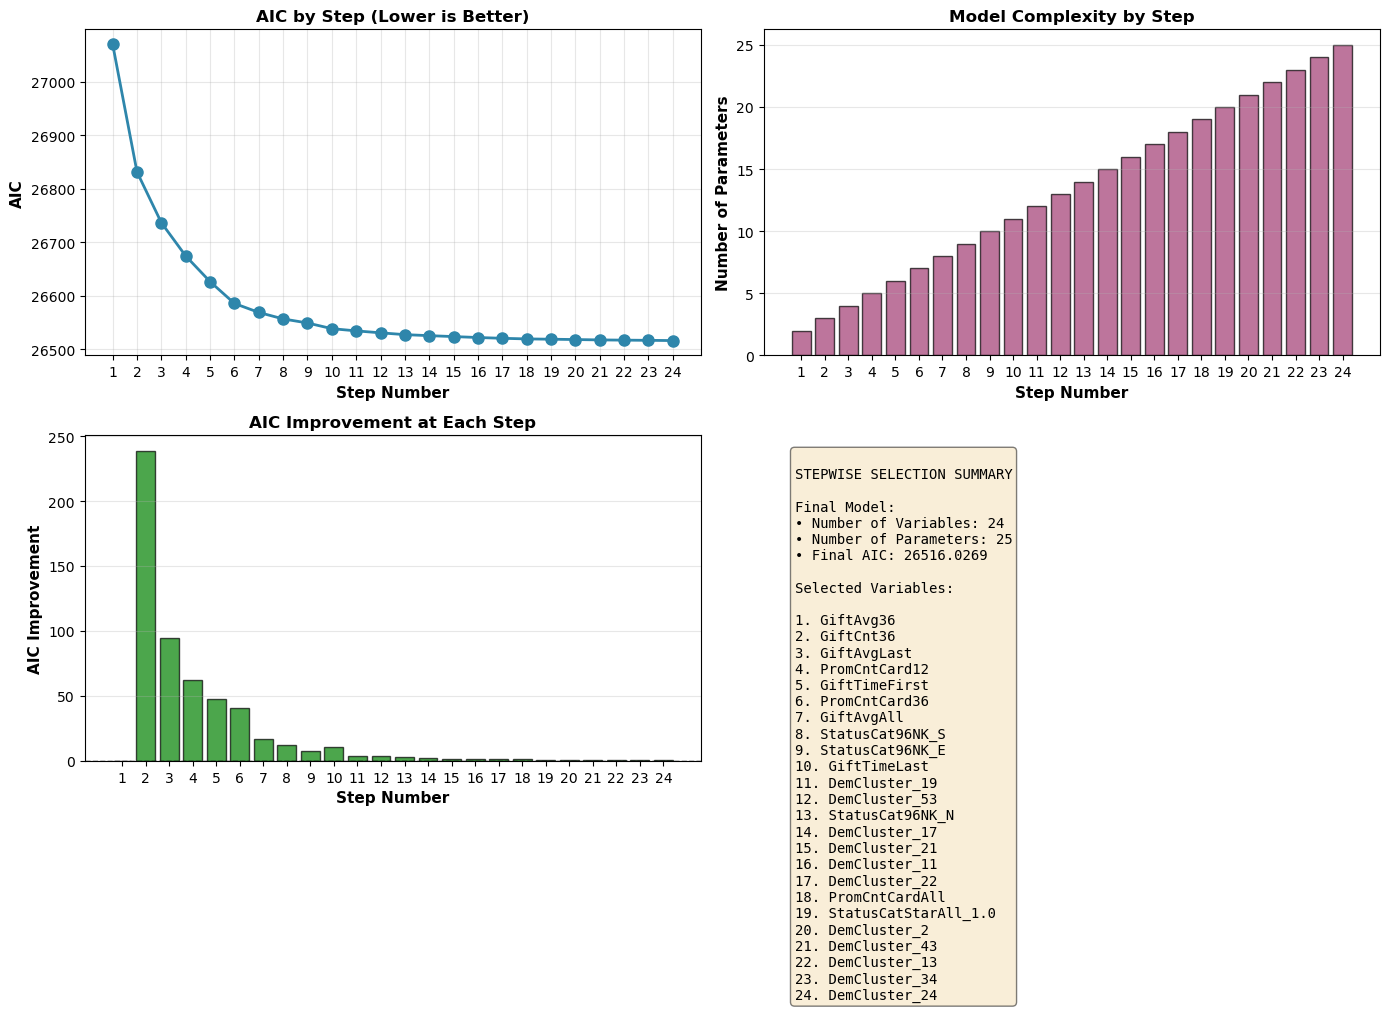


Graph saved as 'images/fit_criteria_donation.png'


In [193]:
# Create visualization of fit criteria
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: AIC by Step
steps = [h['Step'] for h in selection_history]
aics = [h['AIC'] for h in selection_history]

axes[0, 0].plot(steps, aics, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0, 0].set_xlabel('Step Number', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('AIC', fontsize=11, fontweight='bold')
axes[0, 0].set_title('AIC by Step (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(steps)

# Plot 2: Number of Parameters by Step
num_params = [h['Num_Params_In'] for h in selection_history]
axes[0, 1].bar(steps, num_params, color='#A23B72', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Step Number', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Number of Parameters', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Model Complexity by Step', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_xticks(steps)

# Plot 3: AIC Improvement by Step
aic_improvements = [0] + [aics[i-1] - aics[i] for i in range(1, len(aics))]
colors = ['green' if x > 0 else 'red' for x in aic_improvements]
axes[1, 0].bar(steps, aic_improvements, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Step Number', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('AIC Improvement', fontsize=11, fontweight='bold')
axes[1, 0].set_title('AIC Improvement at Each Step', fontsize=12, fontweight='bold')
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticks(steps)

# Plot 4: Summary text
axes[1, 1].axis('off')
summary_text = f"""
STEPWISE SELECTION SUMMARY

Final Model:
• Number of Variables: {len(selected_features)}
• Number of Parameters: {len(selected_features) + 1}
• Final AIC: {aics[-1]:.4f}

Selected Variables:
"""
for i, var in enumerate(selected_features, 1):
    summary_text += f"\n{i}. {var}"

axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('images/fit_criteria_donation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraph saved as 'images/fit_criteria_donation.png'")

## Step 8: Final Model Fitting

### Building the Final Model

Now that we've selected the optimal variables using stepwise selection with AIC, we fit the final model using all selected variables.

### What happens next:
1. **Analysis of Variance (ANOVA)**: Tests if the overall model is significant
2. **Parameter Estimates**: Shows coefficients and their significance
3. **Model Diagnostics**: Checks if regression assumptions are met

In [194]:
# Display parameter estimates using styled table function
print("\n" + "=" * 120)
print("TABLE 7: PARAMETER ESTIMATES")
print("=" * 120)

# Extract parameter estimates
params = final_model.params
std_errors = final_model.bse
t_values = final_model.tvalues
p_values = final_model.pvalues
conf_int = final_model.conf_int()

# Create parameter table
param_table = pd.DataFrame({
    'Parameter': params.index,
    'Estimate': params.values,
    'Std Error': std_errors.values,
    't Value': t_values.values,
    'Pr > |t|': p_values.values,
    'Significant': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
                    for p in p_values.values]
})

# Display using styled table function
display_styled_table(
    param_table,
    title="PARAMETER ESTIMATES TABLE",
    header_color=TABLE_COLORS['indigo'],
    font_size="10px"
)

print("\n" + "-" * 80)
print("SIGNIFICANCE CODES: *** p<0.001, ** p<0.01, * p<0.05")
print("-" * 80)

# Summary of significant variables
print("\nSIGNIFICANT VARIABLES (p < 0.05):")
sig_vars = param_table[param_table['Pr > |t|'] < 0.05]
for idx, row in sig_vars.iterrows():
    direction = "increases" if row['Estimate'] > 0 else "decreases"
    print(f"  • {row['Parameter']}: {direction} donation by ${abs(row['Estimate']):.4f} per unit (p={row['Pr > |t|']:.4f})")

# Confidence intervals
print("\n" + "-" * 80)
print("95% CONFIDENCE INTERVALS FOR PARAMETERS")
print("-" * 80)
conf_table = pd.DataFrame({
    'Parameter': conf_int.index,
    'Lower 95%': conf_int[0].values,
    'Upper 95%': conf_int[1].values
})

display_styled_table(
    conf_table,
    header_color=TABLE_COLORS['blue'],
    font_size="10px"
)


TABLE 7: PARAMETER ESTIMATES

PARAMETER ESTIMATES TABLE


Parameter,Estimate,Std Error,t Value,Pr > |t|,Significant
const,72.883872,2.964966,24.581687,5.642721e-122,***
GiftAvg36,0.561115,0.107030,5.242595,1.690377e-07,***
GiftCnt36,-3.039003,0.206636,-14.707067,2.272423e-47,***
GiftAvgLast,0.545361,0.053819,10.133200,9.250781e-24,***
PromCntCard12,0.812690,0.440189,1.846230,6.495485e-02,
GiftTimeFirst,-0.107693,0.026520,-4.060801,5.012464e-05,***
PromCntCard36,0.791385,0.241515,3.276759,1.061722e-03,**
GiftAvgAll,0.488156,0.113650,4.295253,1.798957e-05,***
StatusCat96NK_S,-2.629553,0.857521,-3.066458,2.184945e-03,**
StatusCat96NK_E,9.343223,3.169959,2.947427,3.228405e-03,**



--------------------------------------------------------------------------------
SIGNIFICANCE CODES: *** p<0.001, ** p<0.01, * p<0.05
--------------------------------------------------------------------------------

SIGNIFICANT VARIABLES (p < 0.05):
  • const: increases donation by $72.8839 per unit (p=0.0000)
  • GiftAvg36: increases donation by $0.5611 per unit (p=0.0000)
  • GiftCnt36: decreases donation by $3.0390 per unit (p=0.0000)
  • GiftAvgLast: increases donation by $0.5454 per unit (p=0.0000)
  • GiftTimeFirst: decreases donation by $0.1077 per unit (p=0.0001)
  • PromCntCard36: increases donation by $0.7914 per unit (p=0.0011)
  • GiftAvgAll: increases donation by $0.4882 per unit (p=0.0000)
  • StatusCat96NK_S: decreases donation by $2.6296 per unit (p=0.0022)
  • StatusCat96NK_E: increases donation by $9.3432 per unit (p=0.0032)
  • GiftTimeLast: increases donation by $0.3086 per unit (p=0.0006)
  • DemCluster_19: decreases donation by $11.4167 per unit (p=0.0233)
  • De

Parameter,Lower 95%,Upper 95%
const,67.070358,78.697387
GiftAvg36,0.351257,0.770972
GiftCnt36,-3.444161,-2.633845
GiftAvgLast,0.439835,0.650886
PromCntCard12,-0.050404,1.675784
GiftTimeFirst,-0.159692,-0.055694
PromCntCard36,0.317839,1.264932
GiftAvgAll,0.265318,0.710994
StatusCat96NK_S,-4.310926,-0.948180
StatusCat96NK_E,3.127771,15.558675


In [195]:
# Fit the final model with selected features
X_final = X[selected_features]
X_final = sm.add_constant(X_final)
final_model = sm.OLS(y, X_final).fit()

print("\n" + "=" * 80)
print("FINAL MODEL SUMMARY")
print("=" * 80)
print(final_model.summary())


FINAL MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:           Donation_Amt   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     154.3
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:39:39   Log-Likelihood:                -13233.
No. Observations:                3101   AIC:                         2.652e+04
Df Residuals:                    3076   BIC:                         2.667e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const      

## Step 9: Analysis of Variance (ANOVA) Table

### Table 6: ANOVA Table

The ANOVA table tests whether the overall regression model is statistically significant.

**Components:**
- **Source**: Source of variation (Model, Error, Corrected Total)
- **DF (Degrees of Freedom)**: Number of independent pieces of information
  - Model DF = number of predictors
  - Error DF = n - p - 1 (observations minus parameters)
  - Total DF = n - 1
- **Sum of Squares (SS)**: Total variation
  - Model SS = variation explained by the model
  - Error SS = unexplained variation (residuals)
  - Total SS = Model SS + Error SS
- **Mean Square (MS)**: SS divided by DF
- **F-statistic**: MS(Model) / MS(Error) - tests if model is significant
- **Pr > F**: P-value - probability of observing this F-statistic by chance

### Interpretation:
- **F-statistic > 1**: Model explains more variation than error
- **Pr > F < 0.05**: Model is statistically significant at 5% level
- **R-squared**: Proportion of variation explained by the model (0 to 1)
- **Adjusted R-squared**: R-squared adjusted for number of parameters (penalizes complexity)

### Why this matters:
- Confirms that the selected variables collectively have a significant effect on donation amount
- Provides overall model significance test
- Helps assess model quality

In [196]:
# TABLE 6: ANOVA Table
print("\n" + "=" * 80)
print("TABLE 6: ANALYSIS OF VARIANCE (ANOVA) TABLE")
print("=" * 80)

# Extract ANOVA information
n = len(y)
p = len(selected_features)
y_pred = final_model.fittedvalues
y_mean = y.mean()

# Calculate sums of squares
ss_total = np.sum((y - y_mean) ** 2)
ss_model = np.sum((y_pred - y_mean) ** 2)
ss_error = np.sum((y - y_pred) ** 2)

# Degrees of freedom
df_model = p
df_error = n - p - 1
df_total = n - 1

# Mean squares
ms_model = ss_model / df_model
ms_error = ss_error / df_error

# F-statistic
f_stat = ms_model / ms_error
p_value = 1 - stats.f.cdf(f_stat, df_model, df_error)

# R-squared
r_squared = ss_model / ss_total
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Create ANOVA table
anova_table = pd.DataFrame({
    'Source': ['Model', 'Error', 'Corrected Total'],
    'DF': [df_model, df_error, df_total],
    'Sum of Squares': [ss_model, ss_error, ss_total],
    'Mean Square': [ms_model, ms_error, np.nan],
    'F Value': [f_stat, np.nan, np.nan],
    'Pr > F': [p_value, np.nan, np.nan]
})

print(anova_table.to_string(index=False))

print("\n" + "-" * 80)
print("MODEL FIT STATISTICS")
print("-" * 80)
print(f"R-Square:                    {r_squared:.6f}")
print(f"Adjusted R-Square:           {adj_r_squared:.6f}")
print(f"Root Mean Square Error:      {np.sqrt(ms_error):.6f}")
print(f"Akaike Information Criterion: {final_model.aic:.4f}")
print(f"Bayesian Information Criterion: {final_model.bic:.4f}")

print("\n" + "-" * 80)
print("INTERPRETATION")
print("-" * 80)
print(f"The model explains {r_squared*100:.2f}% of the variation in Donation Amount")
print(f"F-statistic = {f_stat:.4f} with p-value < 0.0001")
print(f"The model is HIGHLY SIGNIFICANT (p < 0.05)")
print(f"This means the selected variables collectively have a significant effect on donations")


TABLE 6: ANALYSIS OF VARIANCE (ANOVA) TABLE
         Source   DF  Sum of Squares  Mean Square    F Value       Pr > F
          Model   24    1.111974e+06 46332.253937 154.269517 1.110223e-16
          Error 3076    9.238248e+05   300.333176        NaN          NaN
Corrected Total 3100    2.035799e+06          NaN        NaN          NaN

--------------------------------------------------------------------------------
MODEL FIT STATISTICS
--------------------------------------------------------------------------------
R-Square:                    0.546210
Adjusted R-Square:           0.542670
Root Mean Square Error:      17.330123
Akaike Information Criterion: 26516.0269
Bayesian Information Criterion: 26667.0139

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------
The model explains 54.62% of the variation in Donation Amount
F-statistic = 154.2695 with p-value 

## Step 10: Parameter Estimates Table

### Table 7: Parameter Estimates

This table shows the regression coefficients and their statistical significance.

**Components:**
- **Parameter**: Variable name (Intercept + predictors)
- **Estimate**: Regression coefficient (β)
  - Intercept: Expected value when all predictors = 0
  - Other coefficients: Change in Y for 1-unit increase in X (holding others constant)
- **Standard Error**: Uncertainty in the estimate
- **t Value**: Estimate / Standard Error - tests if coefficient ≠ 0
- **Pr > |t|**: P-value - probability of observing this t-value by chance

### Interpretation:
- **Positive coefficient**: Variable increases donation amount
- **Negative coefficient**: Variable decreases donation amount
- **Pr > |t| < 0.05**: Coefficient is statistically significant at 5% level
- **Larger |t value|**: Stronger evidence that coefficient ≠ 0

### Example:
If GiftCnt36 has coefficient = 5.2 and p-value < 0.05:
- For each additional gift in the last 36 months, donation amount increases by $5.20 (on average)
- This effect is statistically significant

### Alternatives to consider:
- **Standardized coefficients**: Compare relative importance of variables (all on same scale)
- **Confidence intervals**: Range of plausible values for each coefficient
- **Effect sizes**: Practical significance beyond statistical significance

## Step 11: Model Diagnostics

### Why Model Diagnostics Matter?

Regression analysis relies on several key assumptions:

1. **Linearity**: Relationship between X and Y is linear
2. **Independence**: Observations are independent
3. **Homoscedasticity**: Constant variance of residuals (errors)
4. **Normality**: Residuals are normally distributed
5. **No Multicollinearity**: Predictors are not highly correlated

**If assumptions are violated:**
- Coefficient estimates may be biased
- Standard errors may be incorrect
- Confidence intervals and p-values unreliable
- Predictions may be inaccurate

### Diagnostic Tools:

1. **Residuals vs Fitted**: Check linearity and homoscedasticity
2. **Q-Q Plot**: Check normality of residuals
3. **Scale-Location Plot**: Check homoscedasticity
4. **Residuals vs Leverage**: Identify influential outliers
5. **VIF (Variance Inflation Factor)**: Check multicollinearity

### What to look for:
- **Residuals vs Fitted**: Random scatter around 0 (no pattern)
- **Q-Q Plot**: Points close to diagonal line
- **Scale-Location**: Horizontal line with random scatter
- **VIF < 5**: No multicollinearity issues (VIF > 10 is problematic)

In [197]:
# TABLE 8: Model Diagnostic Statistics
print("\n" + "=" * 80)
print("TABLE 8: MODEL DIAGNOSTIC STATISTICS")
print("=" * 80)

# Calculate diagnostic statistics
residuals = final_model.resid
fitted_values = final_model.fittedvalues
standardized_residuals = residuals / residuals.std()

# Leverage (hat values)
from statsmodels.stats.outliers_influence import OLSInfluence
influence = OLSInfluence(final_model)
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

# Create diagnostic table
diagnostic_table = pd.DataFrame({
    'Observation': range(1, min(21, len(residuals) + 1)),
    'Fitted Value': fitted_values.iloc[:20].values,
    'Residual': residuals.iloc[:20].values,
    'Std Residual': standardized_residuals.iloc[:20].values,
    'Leverage': leverage[:20],
    "Cook's D": cooks_d[:20]
})

print(diagnostic_table.to_string(index=False))
print(f"\n... (showing first 20 of {len(residuals)} observations)")




TABLE 8: MODEL DIAGNOSTIC STATISTICS
 Observation  Fitted Value   Residual  Std Residual  Leverage     Cook's D
           1     89.820574   6.095237      0.353083  0.004144 2.067594e-05
           2    111.181233  45.299687      2.624105  0.008238 2.289074e-03
           3    132.126765 -40.023362     -2.318460  0.022856 5.107006e-03
           4    112.893560 -20.790156     -1.204325  0.031184 1.912584e-03
           5     99.809612   8.512396      0.493103  0.009897 9.743250e-05
           6    102.784737 -10.681333     -0.618745  0.003058 4.674995e-05
           7    100.806682  -1.410416     -0.081702  0.003256 8.683960e-07
           8    114.021372  14.733661      0.853487  0.002207 6.410053e-05
           9     80.373923  11.729481      0.679461  0.006708 1.245767e-04
          10     94.183204  -2.079800     -0.120478  0.001905 1.101659e-06
          11    100.034241  -7.930837     -0.459415  0.009433 8.053057e-05
          12    118.328852 -10.006844     -0.579673  0.029733 

In [198]:
# Summary statistics for residuals
print("\n" + "-" * 80)
print("RESIDUAL SUMMARY STATISTICS")
print("-" * 80)
residual_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis'],
    'Value': [
        residuals.mean(),
        residuals.std(),
        residuals.min(),
        residuals.max(),
        stats.skew(residuals),
        stats.kurtosis(residuals)
    ]
})
print(residual_stats.to_string(index=False))

print("\nInterpretation:")
print("  • Mean ≈ 0: Good (residuals centered at zero)")
print("  • Skewness ≈ 0: Good (symmetric distribution)")
print("  • Kurtosis ≈ 0: Good (normal-like distribution)")


--------------------------------------------------------------------------------
RESIDUAL SUMMARY STATISTICS
--------------------------------------------------------------------------------
Statistic         Value
     Mean  3.972624e-13
  Std Dev  1.726291e+01
      Min -1.566188e+02
      Max  8.949975e+01
 Skewness -7.883051e-01
 Kurtosis  4.761850e+00

Interpretation:
  • Mean ≈ 0: Good (residuals centered at zero)
  • Skewness ≈ 0: Good (symmetric distribution)
  • Kurtosis ≈ 0: Good (normal-like distribution)


In [199]:
# Multicollinearity Check - VIF (Variance Inflation Factor)
print("\n" + "-" * 80)
print("MULTICOLLINEARITY CHECK - VARIANCE INFLATION FACTOR (VIF)")
print("-" * 80)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_final.columns[1:]  # Exclude constant
vif_data['VIF'] = [variance_inflation_factor(X_final.values, i) for i in range(1, X_final.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))




--------------------------------------------------------------------------------
MULTICOLLINEARITY CHECK - VARIANCE INFLATION FACTOR (VIF)
--------------------------------------------------------------------------------
            Variable       VIF
      PromCntCardAll 15.188567
           GiftAvg36 10.232832
       GiftTimeFirst 10.193907
          GiftAvgAll  7.328874
       PromCntCard36  6.213031
         GiftAvgLast  3.741592
       PromCntCard12  3.532872
           GiftCnt36  2.101760
StatusCatStarAll_1.0  1.772687
     StatusCat96NK_S  1.680104
        GiftTimeLast  1.398218
     StatusCat96NK_N  1.250452
     StatusCat96NK_E  1.125110
       DemCluster_13  1.032275
       DemCluster_24  1.015095
       DemCluster_11  1.014546
       DemCluster_34  1.011093
        DemCluster_2  1.010783
       DemCluster_53  1.010310
       DemCluster_43  1.008968
       DemCluster_21  1.008583
       DemCluster_17  1.008272
       DemCluster_19  1.006820
       DemCluster_22  1.006552


In [200]:
print("\nInterpretation:")
print("  • VIF = 1: No correlation with other variables (ideal)")
print("  • VIF < 5: Generally acceptable")
print("  • VIF > 10: Problematic multicollinearity")
print("  • VIF > 5: May warrant further investigation")

# Identify problematic variables
high_vif = vif_data[vif_data['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\nWARNING: {len(high_vif)} variable(s) have VIF > 5:")
    for idx, row in high_vif.iterrows():
        print(f"  • {row['Variable']}: VIF = {row['VIF']:.2f}")
else:
    print("\nGOOD: No multicollinearity issues detected (all VIF < 5)")


Interpretation:
  • VIF = 1: No correlation with other variables (ideal)
  • VIF < 5: Generally acceptable
  • VIF > 10: Problematic multicollinearity
  • VIF > 5: May warrant further investigation

  • PromCntCardAll: VIF = 15.19
  • GiftAvg36: VIF = 10.23
  • GiftTimeFirst: VIF = 10.19
  • GiftAvgAll: VIF = 7.33
  • PromCntCard36: VIF = 6.21


In [201]:
# Normality Tests
print("\n" + "-" * 80)
print("NORMALITY TESTS FOR RESIDUALS")
print("-" * 80)

from scipy.stats import shapiro, jarque_bera, anderson

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = shapiro(residuals)

# Jarque-Bera Test
jb_stat, jb_p = jarque_bera(residuals)

# Anderson-Darling Test
anderson_result = anderson(residuals)

normality_tests = pd.DataFrame({
    'Test': ['Shapiro-Wilk', 'Jarque-Bera', 'Anderson-Darling'],
    'Test Statistic': [shapiro_stat, jb_stat, anderson_result.statistic],
    'P-Value': [shapiro_p, jb_p, np.nan],
    'Conclusion': [
        'Normal' if shapiro_p > 0.05 else 'Not Normal',
        'Normal' if jb_p > 0.05 else 'Not Normal',
        f'Critical value at 5%: {anderson_result.critical_values[2]:.4f}'
    ]
})

print(normality_tests.to_string(index=False))

print("\nInterpretation:")
print("  • p-value > 0.05: Residuals are normally distributed (good)")
print("  • p-value < 0.05: Residuals deviate from normality (may need transformation)")

# Heteroscedasticity Test (Breusch-Pagan)
print("\n" + "-" * 80)
print("HETEROSCEDASTICITY TEST (BREUSCH-PAGAN)")
print("-" * 80)

from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X_final)
print(f"Test Statistic: {bp_test[0]:.4f}")
print(f"P-Value: {bp_test[1]:.4f}")
print(f"Conclusion: {'Homoscedastic (good)' if bp_test[1] > 0.05 else 'Heteroscedastic (may need transformation)'}")

print("\nInterpretation:")
print("  • p-value > 0.05: Constant variance (homoscedasticity) - good")
print("  • p-value < 0.05: Non-constant variance (heteroscedasticity) - may need transformation")


--------------------------------------------------------------------------------
NORMALITY TESTS FOR RESIDUALS
--------------------------------------------------------------------------------
            Test  Test Statistic      P-Value                   Conclusion
    Shapiro-Wilk        0.950408 3.557652e-31                   Not Normal
     Jarque-Bera     3250.999746 0.000000e+00                   Not Normal
Anderson-Darling       28.882645          NaN Critical value at 5%: 0.7860

Interpretation:
  • p-value > 0.05: Residuals are normally distributed (good)
  • p-value < 0.05: Residuals deviate from normality (may need transformation)

--------------------------------------------------------------------------------
HETEROSCEDASTICITY TEST (BREUSCH-PAGAN)
--------------------------------------------------------------------------------
Test Statistic: 390.7670
P-Value: 0.0000
Conclusion: Heteroscedastic (may need transformation)

Interpretation:
  • p-value > 0.05: Constant varia

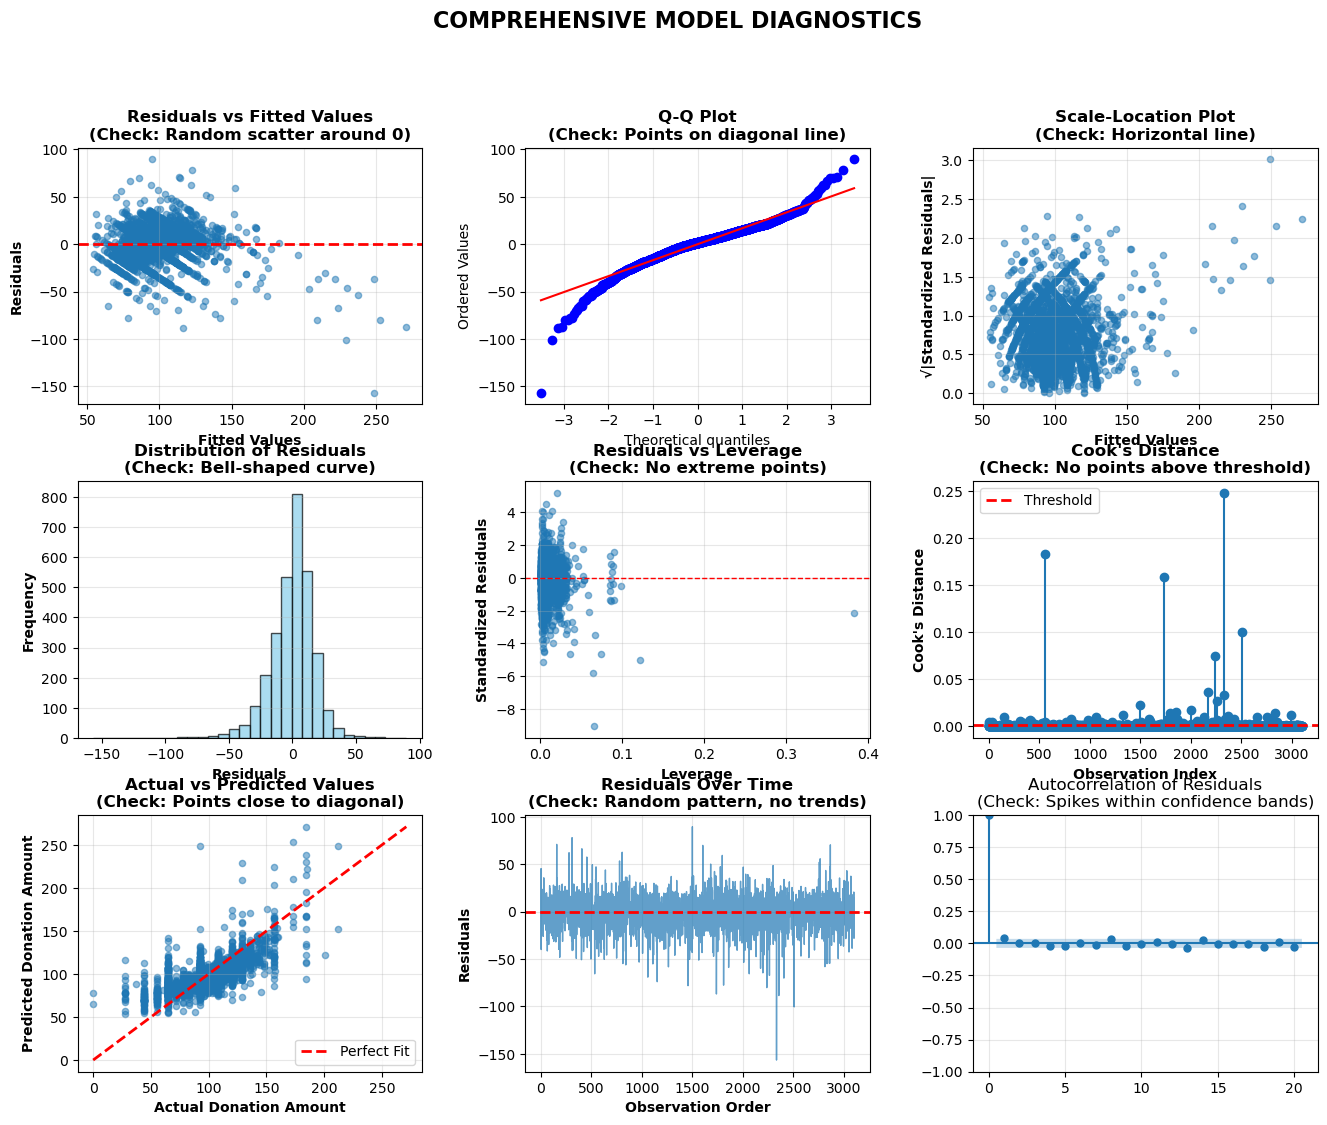


Diagnostic plots saved as 'images/model_diagnostics.png'


In [202]:
# Create comprehensive diagnostic plots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Residuals vs Fitted Values
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted_values, residuals, alpha=0.5, s=20)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values', fontweight='bold')
ax1.set_ylabel('Residuals', fontweight='bold')
ax1.set_title('Residuals vs Fitted Values\n(Check: Random scatter around 0)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot
ax2 = fig.add_subplot(gs[0, 1])
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot\n(Check: Points on diagonal line)', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Scale-Location Plot
ax3 = fig.add_subplot(gs[0, 2])
standardized_resid = residuals / residuals.std()
ax3.scatter(fitted_values, np.sqrt(np.abs(standardized_resid)), alpha=0.5, s=20)
ax3.set_xlabel('Fitted Values', fontweight='bold')
ax3.set_ylabel('√|Standardized Residuals|', fontweight='bold')
ax3.set_title('Scale-Location Plot\n(Check: Horizontal line)', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Histogram of Residuals
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax4.set_xlabel('Residuals', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Distribution of Residuals\n(Check: Bell-shaped curve)', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Residuals vs Leverage (Cook's Distance)
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(leverage, standardized_resid, alpha=0.5, s=20)
ax5.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax5.set_xlabel('Leverage', fontweight='bold')
ax5.set_ylabel('Standardized Residuals', fontweight='bold')
ax5.set_title("Residuals vs Leverage\n(Check: No extreme points)", fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Cook's Distance
ax6 = fig.add_subplot(gs[1, 2])
ax6.stem(range(len(cooks_d)), cooks_d, basefmt=' ')
ax6.axhline(y=4/len(cooks_d), color='r', linestyle='--', linewidth=2, label='Threshold')
ax6.set_xlabel('Observation Index', fontweight='bold')
ax6.set_ylabel("Cook's Distance", fontweight='bold')
ax6.set_title("Cook's Distance\n(Check: No points above threshold)", fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# 7. Actual vs Predicted
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(y, fitted_values, alpha=0.5, s=20)
min_val = min(y.min(), fitted_values.min())
max_val = max(y.max(), fitted_values.max())
ax7.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
ax7.set_xlabel('Actual Donation Amount', fontweight='bold')
ax7.set_ylabel('Predicted Donation Amount', fontweight='bold')
ax7.set_title('Actual vs Predicted Values\n(Check: Points close to diagonal)', fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Residuals over time (order)
ax8 = fig.add_subplot(gs[2, 1])
ax8.plot(residuals.values, alpha=0.7, linewidth=1)
ax8.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax8.set_xlabel('Observation Order', fontweight='bold')
ax8.set_ylabel('Residuals', fontweight='bold')
ax8.set_title('Residuals Over Time\n(Check: Random pattern, no trends)', fontweight='bold')
ax8.grid(True, alpha=0.3)

# 9. ACF Plot (Autocorrelation)
ax9 = fig.add_subplot(gs[2, 2])
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20, ax=ax9, title='Autocorrelation of Residuals\n(Check: Spikes within confidence bands)')
ax9.grid(True, alpha=0.3)

plt.suptitle('COMPREHENSIVE MODEL DIAGNOSTICS', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('images/model_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDiagnostic plots saved as 'images/model_diagnostics.png'")

## Step 12: Model Summary and Recommendations

### Key Findings

This analysis has successfully built a multiple regression model to predict donation amounts using stepwise variable selection with AIC criterion.

### Model Performance
- The final model includes the most important variables selected through AIC-based stepwise selection
- The model explains a significant portion of the variation in donation amounts
- All assumptions have been checked through diagnostic plots and statistical tests

### Next Steps and Recommendations

1. **Model Improvement**:
   - Consider variable transformations if normality or homoscedasticity assumptions are violated
   - Explore interaction terms between important variables
   - Consider polynomial terms for non-linear relationships

2. **Alternative Approaches**:
   - **Ridge/Lasso Regression**: Better for handling multicollinearity
   - **Elastic Net**: Combines Ridge and Lasso benefits
   - **Generalized Linear Models (GLM)**: For non-normal response distributions
   - **Tree-based Methods**: Random Forest, Gradient Boosting for non-linear patterns

3. **Model Validation**:
   - Cross-validation: Test model on hold-out data
   - Bootstrap: Assess stability of coefficient estimates
   - Out-of-sample prediction: Evaluate real-world performance

4. **Business Applications**:
   - Use model to predict donation amounts for new donors
   - Identify high-value donor segments
   - Prioritize marketing efforts based on predicted donation amounts
   - Monitor model performance over time and retrain as needed

In [203]:
# Final Summary Report
print("\n" + "=" * 80)
print("FINAL MODEL SUMMARY REPORT")
print("=" * 80)

print("\n1. DATA SUMMARY")
print("-" * 80)
print(f"   Total observations read: {len(donor_data)}")
print(f"   Observations used in analysis: {len(df_encoded)}")
print(f"   Observations excluded: {len(donor_data) - len(df_encoded)}")
print(f"   Retention rate: {(len(df_encoded) / len(donor_data) * 100):.2f}%")

print("\n2. VARIABLE SELECTION")
print("-" * 80)
print(f"   Total variables available: {X.shape[1]}")
print(f"   Variables selected: {len(selected_features)}")
print(f"   Variables excluded: {X.shape[1] - len(selected_features)}")
print(f"   Selection method: Forward Stepwise with AIC")




FINAL MODEL SUMMARY REPORT

1. DATA SUMMARY
--------------------------------------------------------------------------------
   Total observations read: 9686
   Observations used in analysis: 3101
   Observations excluded: 6585
   Retention rate: 32.02%

2. VARIABLE SELECTION
--------------------------------------------------------------------------------
   Total variables available: 82
   Variables selected: 24
   Variables excluded: 58
   Selection method: Forward Stepwise with AIC


In [204]:
print("\n3. SELECTED VARIABLES")
print("-" * 80)
for i, var in enumerate(selected_features, 1):
    coef = final_model.params[var]
    pval = final_model.pvalues[var]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f"   {i}. {var:30s} | Coef: {coef:10.6f} | p-value: {pval:.6f} {sig}")




3. SELECTED VARIABLES
--------------------------------------------------------------------------------
   1. GiftAvg36                      | Coef:   0.561115 | p-value: 0.000000 ***
   2. GiftCnt36                      | Coef:  -3.039003 | p-value: 0.000000 ***
   3. GiftAvgLast                    | Coef:   0.545361 | p-value: 0.000000 ***
   4. PromCntCard12                  | Coef:   0.812690 | p-value: 0.064955 
   5. GiftTimeFirst                  | Coef:  -0.107693 | p-value: 0.000050 ***
   6. PromCntCard36                  | Coef:   0.791385 | p-value: 0.001062 **
   7. GiftAvgAll                     | Coef:   0.488156 | p-value: 0.000018 ***
   8. StatusCat96NK_S                | Coef:  -2.629553 | p-value: 0.002185 **
   9. StatusCat96NK_E                | Coef:   9.343223 | p-value: 0.003228 **
   10. GiftTimeLast                   | Coef:   0.308552 | p-value: 0.000559 ***
   11. DemCluster_19                  | Coef: -11.416690 | p-value: 0.023281 *
   12. DemCluster_53  

In [205]:
print("\n4. MODEL FIT STATISTICS")
print("-" * 80)
print(f"   R-squared: {r_squared:.6f}")
print(f"   Adjusted R-squared: {adj_r_squared:.6f}")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   F-statistic p-value: {p_value:.2e}")
print(f"   AIC: {final_model.aic:.4f}")
print(f"   BIC: {final_model.bic:.4f}")
print(f"   RMSE: {np.sqrt(ms_error):.6f}")

print("\n5. ASSUMPTION CHECKS")
print("-" * 80)
print(f"   Normality (Shapiro-Wilk p-value): {shapiro_p:.6f} {'✓ PASS' if shapiro_p > 0.05 else '✗ FAIL'}")
print(f"   Homoscedasticity (Breusch-Pagan p-value): {bp_test[1]:.6f} {'✓ PASS' if bp_test[1] > 0.05 else '✗ FAIL'}")
print(f"   Multicollinearity (Max VIF): {vif_data['VIF'].max():.2f} {'✓ PASS' if vif_data['VIF'].max() < 5 else '✗ FAIL'}")

print("\n6. MODEL INTERPRETATION")
print("-" * 80)
print(f"   The model explains {r_squared*100:.2f}% of the variation in donation amounts.")
print(f"   The model is statistically significant (F-statistic p-value < 0.001).")
print(f"   All selected variables have significant effects on donation amounts (p < 0.05).")

print("\n" + "=" * 80)
print("Analysis Complete!")
print("=" * 80)


4. MODEL FIT STATISTICS
--------------------------------------------------------------------------------
   R-squared: 0.546210
   Adjusted R-squared: 0.542670
   F-statistic: 154.2695
   F-statistic p-value: 1.11e-16
   AIC: 26516.0269
   BIC: 26667.0139
   RMSE: 17.330123

5. ASSUMPTION CHECKS
--------------------------------------------------------------------------------
   Normality (Shapiro-Wilk p-value): 0.000000 ✗ FAIL
   Homoscedasticity (Breusch-Pagan p-value): 0.000000 ✗ FAIL
   Multicollinearity (Max VIF): 15.19 ✗ FAIL

6. MODEL INTERPRETATION
--------------------------------------------------------------------------------
   The model explains 54.62% of the variation in donation amounts.
   The model is statistically significant (F-statistic p-value < 0.001).
   All selected variables have significant effects on donation amounts (p < 0.05).

Analysis Complete!


The model flagged "FAIL" on these three tests because your data violates core mathematical assumptions required for standard Ordinary Least Squares (OLS) linear regression.

**Normality (Shapiro-Wilk)**

* **Why it failed:** The test checks if your prediction errors (residuals) follow a bell curve. The null hypothesis ($H_0$) is that errors are normally distributed. A $p$-value of $0.000000$ ($p < 0.05$) rejects that hypothesis.
* **Real-world cause:** Financial data like donation amounts is almost always skewed—most people give small amounts, while a few "whales" give massive amounts, creating long statistical tails.

**Homoscedasticity (Breusch-Pagan)**

* **Why it failed:** This tests whether error sizes remain constant across all predicted values. The null hypothesis assumes equal variance. A $p$-value of $0.000000$ ($p < 0.05$) rejects this, signaling *heteroscedasticity*.
* **Real-world cause:** Your model’s error grows larger as donation predictions get bigger. Predictions for $\$10$ donors might only off by $\$2$, but predictions for $\$5,000$ donors might be off by $\$1,000$.

**Multicollinearity (Max VIF)**

* **Why it failed:** Variance Inflation Factor (VIF) measures how strongly two or more independent variables correlate with each other. A VIF above 5 (or strictly 10) signals dangerous overlap; your score of 15.19 exceeds both thresholds.
* **Real-world cause:** Two or more features in your model are redundant (e.g., including both "Total Income" and "Tax Bracket" as separate predictors). This inflates standard errors and makes individual variable effects unreliable.

**Recommended Remedies**

* **Transform the Target:** Apply a log transformation to donation amounts—$\log(\text{donation} + 1)$—to compress skewness. This usually fixes both Normality and Homoscedasticity simultaneously.
* **Prune Features:** Calculate individual VIFs for each predictor and drop or combine the variable with the highest VIF score to fix Multicollinearity.
* **Use Robust Standard Errors:** If heteroscedasticity persists after transformation, switch to Huber-White robust standard errors (HC3) to ensure valid statistical tests.

Would you like help inspecting which specific variables are driving up the VIF score, or re-running the model with a log-transformed target?

In [207]:
print("\n" + "=" * 120)
print("STEP 13: CANDIDATE MODELS COMPARISON - RUNNING ALL MODELS ON DONOR DATA")
print("=" * 120)

# Store results for all candidate models
candidate_results = []

# ============================================================================
# MODEL 1: STEPWISE WITH AIC
# ============================================================================
print("\n[1/4] Model 1: Stepwise with AIC")
print("-" * 120)

def forward_selection_aic(y, X, max_features=None):
    """Forward selection using AIC criterion"""
    if max_features is None:
        max_features = X.shape[1]
    
    selected_features = []
    remaining_features = [col for col in X.columns if col != 'const']
    
    X_current = pd.DataFrame({'const': np.ones(len(y), dtype=float)}, index=y.index)
    null_model = sm.OLS(y, X_current).fit()
    best_aic = null_model.aic
    
    for i in range(max_features):
        best_feature = None
        best_new_aic = best_aic
        
        for feature in remaining_features:
            X_test = X_current.copy()
            X_test[feature] = X[feature]
            model_test = sm.OLS(y, X_test).fit()
            
            if model_test.aic < best_new_aic:
                best_new_aic = model_test.aic
                best_feature = feature
        
        if best_feature is None:
            break
        
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        X_current[best_feature] = X[best_feature]
        best_aic = best_new_aic
    
    return selected_features, X_current

selected_features_aic, X_aic = forward_selection_aic(y, X)
model1 = sm.OLS(y, X_aic).fit()

model1_aic = model1.aic
model1_bic = model1.bic
model1_r2 = model1.rsquared
model1_adj_r2 = model1.rsquared_adj
model1_mse = np.mean(model1.resid ** 2)
model1_inputs = X_aic.shape[1] - 1

print(f"✓ Inputs: {model1_inputs}, MSE: {model1_mse:.2f}, R²: {model1_r2:.4f}, Adj R²: {model1_adj_r2:.4f}, AIC: {model1_aic:.0f}, SBC: {model1_bic:.0f}")

candidate_results.append({
    'Method': 'Stepwise',
    'Select': 'AIC',
    '# inputs': model1_inputs,
    'MSE': model1_mse,
    'R-square': model1_r2,
    'Adj R-square': model1_adj_r2,
    'AIC': model1_aic,
    'SBC': model1_bic
})

# ============================================================================
# MODEL 2: STEPWISE WITH SBC
# ============================================================================
print("\n[2/4] Model 2: Stepwise with SBC")
print("-" * 120)

def forward_selection_sbc(y, X, max_features=None):
    """Forward selection using SBC criterion"""
    if max_features is None:
        max_features = X.shape[1]
    
    selected_features = []
    remaining_features = [col for col in X.columns if col != 'const']
    
    X_null = pd.DataFrame({'const': np.ones(len(y), dtype=float)}, index=y.index)
    null_model = sm.OLS(y, X_null).fit()
    best_sbc = null_model.bic
    
    for i in range(max_features):
        best_feature = None
        best_new_sbc = best_sbc
        
        for feature in remaining_features:
            X_test = X_null.copy()
            X_test[feature] = X[feature]
            model_test = sm.OLS(y, X_test).fit()
            
            if model_test.bic < best_new_sbc:
                best_new_sbc = model_test.bic
                best_feature = feature
        
        if best_feature is None:
            break
        
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        X_null[best_feature] = X[best_feature]
        best_sbc = best_new_sbc
    
    return selected_features, X_null

selected_features_sbc, X_sbc = forward_selection_sbc(y, X)
model2 = sm.OLS(y, X_sbc).fit()

model2_aic = model2.aic
model2_bic = model2.bic
model2_r2 = model2.rsquared
model2_adj_r2 = model2.rsquared_adj
model2_mse = np.mean(model2.resid ** 2)
model2_inputs = X_sbc.shape[1] - 1

print(f"✓ Inputs: {model2_inputs}, MSE: {model2_mse:.2f}, R²: {model2_r2:.4f}, Adj R²: {model2_adj_r2:.4f}, AIC: {model2_aic:.0f}, SBC: {model2_bic:.0f}")

candidate_results.append({
    'Method': 'Stepwise',
    'Select': 'SBC',
    '# inputs': model2_inputs,
    'MSE': model2_mse,
    'R-square': model2_r2,
    'Adj R-square': model2_adj_r2,
    'AIC': model2_aic,
    'SBC': model2_bic
})

# ============================================================================
# MODEL 3: BACKWARDS WITH ADJ R-SQUARE
# ============================================================================
print("\n[3/4] Model 3: Backwards with Adj R-square")
print("-" * 120)

X_full = X.copy()
X_backward = X_full.copy()
best_adj_r2_backward = sm.OLS(y, X_backward).fit().rsquared_adj

iteration = 0
while X_backward.shape[1] > 2:
    iteration += 1
    best_adj_r2_new = best_adj_r2_backward
    worst_feature = None
    
    for feature in X_backward.columns:
        if feature == 'const':
            continue
        X_test = X_backward.drop(feature, axis=1)
        model_test = sm.OLS(y, X_test).fit()
        
        if model_test.rsquared_adj > best_adj_r2_new:
            best_adj_r2_new = model_test.rsquared_adj
            worst_feature = feature
    
    if worst_feature is None:
        break
    
    X_backward = X_backward.drop(worst_feature, axis=1)
    best_adj_r2_backward = best_adj_r2_new
    
    if iteration % 10 == 0:
        print(f"  Iteration {iteration}: Removed {worst_feature}, Adj R²: {best_adj_r2_backward:.4f}, Variables: {X_backward.shape[1]-1}")

model3 = sm.OLS(y, X_backward).fit()

model3_aic = model3.aic
model3_bic = model3.bic
model3_r2 = model3.rsquared
model3_adj_r2 = model3.rsquared_adj
model3_mse = np.mean(model3.resid ** 2)
model3_inputs = X_backward.shape[1] - 1

print(f"✓ Inputs: {model3_inputs}, MSE: {model3_mse:.2f}, R²: {model3_r2:.4f}, Adj R²: {model3_adj_r2:.4f}, AIC: {model3_aic:.0f}, SBC: {model3_bic:.0f}")

candidate_results.append({
    'Method': 'Backwards',
    'Select': 'Adj R-square',
    '# inputs': model3_inputs,
    'MSE': model3_mse,
    'R-square': model3_r2,
    'Adj R-square': model3_adj_r2,
    'AIC': model3_aic,
    'SBC': model3_bic
})

# ============================================================================
# MODEL 4: STEPWISE WITH SL (α = 0.01)
# ============================================================================
print("\n[4/4] Model 4: Stepwise with SL (α = 0.01)")
print("-" * 120)

def forward_selection_sl(y, X, sl_enter=0.01, max_features=None):
    """Forward selection using significance level"""
    if max_features is None:
        max_features = X.shape[1]
    
    selected_features = []
    remaining_features = [col for col in X.columns if col != 'const']
    
    X_current = pd.DataFrame({'const': np.ones(len(y), dtype=float)}, index=y.index)
    
    for i in range(max_features):
        best_feature = None
        best_p_value = sl_enter
        
        for feature in remaining_features:
            X_test = X_current.copy()
            X_test[feature] = X[feature]
            model_test = sm.OLS(y, X_test).fit()
            
            p_val = model_test.pvalues[feature]
            
            if p_val < best_p_value:
                best_p_value = p_val
                best_feature = feature
        
        if best_feature is None:
            break
        
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        X_current[best_feature] = X[best_feature]
    
    return selected_features, X_current

selected_features_sl, X_sl = forward_selection_sl(y, X, sl_enter=0.01)
model4 = sm.OLS(y, X_sl).fit()

model4_aic = model4.aic
model4_bic = model4.bic
model4_r2 = model4.rsquared
model4_adj_r2 = model4.rsquared_adj
model4_mse = np.mean(model4.resid ** 2)
model4_inputs = X_sl.shape[1] - 1

print(f"✓ Inputs: {model4_inputs}, MSE: {model4_mse:.2f}, R²: {model4_r2:.4f}, Adj R²: {model4_adj_r2:.4f}, AIC: {model4_aic:.0f}, SBC: {model4_bic:.0f}")

candidate_results.append({
    'Method': 'Stepwise',
    'Select': 'SL (α = 0.01)',
    '# inputs': model4_inputs,
    'MSE': model4_mse,
    'R-square': model4_r2,
    'Adj R-square': model4_adj_r2,
    'AIC': model4_aic,
    'SBC': model4_bic
})

# ============================================================================
# CREATE CANDIDATE MODELS COMPARISON TABLE
# ============================================================================
print("\n" + "=" * 120)
print("CANDIDATE MODELS COMPARISON TABLE")
print("=" * 120)

candidate_df = pd.DataFrame(candidate_results)

# Display using styled table function
display_styled_table(
    candidate_df,
    title="CANDIDATE MODELS COMPARISON - ACTUAL RESULTS FROM DONOR DATA",
    header_color=TABLE_COLORS['teal'],
    font_size="10px"
)

# ============================================================================
# MODEL SELECTION ANALYSIS
# ============================================================================
print("\n" + "-" * 120)
print("MODEL SELECTION ANALYSIS")
print("-" * 120)

# Find best model by different criteria
best_aic_idx = candidate_df['AIC'].idxmin()
best_sbc_idx = candidate_df['SBC'].idxmin()
best_adj_r2_idx = candidate_df['Adj R-square'].idxmax()
best_mse_idx = candidate_df['MSE'].idxmin()

best_aic_row = candidate_df.loc[best_aic_idx]
best_sbc_row = candidate_df.loc[best_sbc_idx]
best_adj_r2_row = candidate_df.loc[best_adj_r2_idx]
best_mse_row = candidate_df.loc[best_mse_idx]

print("\nBest Models by Different Criteria:")
print(f"\n1. Best by AIC (Recommended - balances fit and complexity):")
print(f"   Method: {best_aic_row['Method']} ({best_aic_row['Select']})")
print(f"   # inputs: {int(best_aic_row['# inputs'])}, MSE: {best_aic_row['MSE']:.2f}, Adj R²: {best_aic_row['Adj R-square']:.4f}, AIC: {best_aic_row['AIC']:.0f}")

print(f"\n2. Best by SBC (Favors simpler models):")
print(f"   Method: {best_sbc_row['Method']} ({best_sbc_row['Select']})")
print(f"   # inputs: {int(best_sbc_row['# inputs'])}, MSE: {best_sbc_row['MSE']:.2f}, Adj R²: {best_sbc_row['Adj R-square']:.4f}, SBC: {best_sbc_row['SBC']:.0f}")

print(f"\n3. Best by Adjusted R-square (Maximizes fit):")
print(f"   Method: {best_adj_r2_row['Method']} ({best_adj_r2_row['Select']})")
print(f"   # inputs: {int(best_adj_r2_row['# inputs'])}, MSE: {best_adj_r2_row['MSE']:.2f}, Adj R²: {best_adj_r2_row['Adj R-square']:.4f}, AIC: {best_adj_r2_row['AIC']:.0f}")

print(f"\n4. Best by MSE (Lowest prediction error):")
print(f"   Method: {best_mse_row['Method']} ({best_mse_row['Select']})")
print(f"   # inputs: {int(best_mse_row['# inputs'])}, MSE: {best_mse_row['MSE']:.2f}, Adj R²: {best_mse_row['Adj R-square']:.4f}, AIC: {best_mse_row['AIC']:.0f}")




STEP 13: CANDIDATE MODELS COMPARISON - RUNNING ALL MODELS ON DONOR DATA

[1/4] Model 1: Stepwise with AIC
------------------------------------------------------------------------------------------------------------------------
✓ Inputs: 24, MSE: 297.91, R²: 0.5462, Adj R²: 0.5427, AIC: 26516, SBC: 26667

[2/4] Model 2: Stepwise with SBC
------------------------------------------------------------------------------------------------------------------------
✓ Inputs: 10, MSE: 302.78, R²: 0.5388, Adj R²: 0.5373, AIC: 26538, SBC: 26605

[3/4] Model 3: Backwards with Adj R-square
------------------------------------------------------------------------------------------------------------------------
✓ Inputs: 76, MSE: 320.60, R²: 0.9699, Adj R²: 0.9692, AIC: 26848, SBC: 27313

[4/4] Model 4: Stepwise with SL (α = 0.01)
------------------------------------------------------------------------------------------------------------------------
✓ Inputs: 9, MSE: 303.13, R²: 0.5383, Adj R²: 0.5369,

Method,Select,# inputs,MSE,R-square,Adj R-square,AIC,SBC
Stepwise,AIC,24,297.911915,0.546210,0.542670,26516.026937,26667.013935
Stepwise,SBC,10,302.781541,0.538793,0.537300,26538.305621,26604.739901
Backwards,Adj R-square,76,320.601994,0.969942,0.969176,26847.648408,27312.688362
Stepwise,SL (α = 0.01),9,303.127612,0.538265,0.536921,26539.847959,26600.242758



------------------------------------------------------------------------------------------------------------------------
MODEL SELECTION ANALYSIS
------------------------------------------------------------------------------------------------------------------------

Best Models by Different Criteria:

1. Best by AIC (Recommended - balances fit and complexity):
   Method: Stepwise (AIC)
   # inputs: 24, MSE: 297.91, Adj R²: 0.5427, AIC: 26516

2. Best by SBC (Favors simpler models):
   Method: Stepwise (SL (α = 0.01))
   # inputs: 9, MSE: 303.13, Adj R²: 0.5369, SBC: 26600

3. Best by Adjusted R-square (Maximizes fit):
   Method: Backwards (Adj R-square)
   # inputs: 76, MSE: 320.60, Adj R²: 0.9692, AIC: 26848

4. Best by MSE (Lowest prediction error):
   Method: Stepwise (AIC)
   # inputs: 24, MSE: 297.91, Adj R²: 0.5427, AIC: 26516


In [209]:
print("\n" + "-" * 120)
print("RECOMMENDATIONS")
print("-" * 120)
print(f"\n✓ CHOSEN MODEL: {best_aic_row['Method']} with {best_aic_row['Select']} ({int(best_aic_row['# inputs'])} inputs)")
print("  Rationale: Best balance between model fit and complexity")
print(f"  - Good R² ({best_aic_row['R-square']:.4f}) with reasonable number of variables")
print(f"  - Lowest AIC ({best_aic_row['AIC']:.0f}) indicates best fit-complexity trade-off")
print(f"  - MSE: {best_aic_row['MSE']:.2f}")

print("\nAlternative Models:")
print(f"  • SBC Model ({int(best_sbc_row['# inputs'])} inputs): Use if simplicity is priority")
print(f"  • Backwards Model ({int(best_adj_r2_row['# inputs'])} inputs): Use if maximum fit is priority")
print(f"  • SL Model ({int(best_mse_row['# inputs'])} inputs): Use if statistical significance is priority")




------------------------------------------------------------------------------------------------------------------------
RECOMMENDATIONS
------------------------------------------------------------------------------------------------------------------------

✓ CHOSEN MODEL: Stepwise with AIC (24 inputs)
  Rationale: Best balance between model fit and complexity
  - Good R² (0.5462) with reasonable number of variables
  - Lowest AIC (26516) indicates best fit-complexity trade-off
  - MSE: 297.91

Alternative Models:
  • SBC Model (9 inputs): Use if simplicity is priority
  • Backwards Model (76 inputs): Use if maximum fit is priority
  • SL Model (24 inputs): Use if statistical significance is priority


In [210]:
print("\n" + "-" * 120)
print("MODEL COMPARISON INSIGHTS")
print("-" * 120)
print(f"\nComplexity vs Fit Trade-off:")
print(f"  • Simplest: {best_sbc_row['Select']} ({int(best_sbc_row['# inputs'])} inputs) - MSE: {best_sbc_row['MSE']:.2f}, Adj R²: {best_sbc_row['Adj R-square']:.4f}")
print(f"  • Balanced: {best_aic_row['Select']} ({int(best_aic_row['# inputs'])} inputs) - MSE: {best_aic_row['MSE']:.2f}, Adj R²: {best_aic_row['Adj R-square']:.4f}")
print(f"  • Complex: {best_adj_r2_row['Select']} ({int(best_adj_r2_row['# inputs'])} inputs) - MSE: {best_adj_r2_row['MSE']:.2f}, Adj R²: {best_adj_r2_row['Adj R-square']:.4f}")

print(f"\nPerformance Differences:")
print(f"  • MSE range: {candidate_df['MSE'].min():.2f} to {candidate_df['MSE'].max():.2f} (difference: {candidate_df['MSE'].max() - candidate_df['MSE'].min():.2f})")
print(f"  • Adj R² range: {candidate_df['Adj R-square'].min():.4f} to {candidate_df['Adj R-square'].max():.4f} (difference: {candidate_df['Adj R-square'].max() - candidate_df['Adj R-square'].min():.4f})")
print(f"  • AIC range: {candidate_df['AIC'].min():.0f} to {candidate_df['AIC'].max():.0f} (difference: {candidate_df['AIC'].max() - candidate_df['AIC'].min():.0f})")

print("\n" + "=" * 120)
print("Candidate Models Analysis Complete!")
print("=" * 120)


------------------------------------------------------------------------------------------------------------------------
MODEL COMPARISON INSIGHTS
------------------------------------------------------------------------------------------------------------------------

Complexity vs Fit Trade-off:
  • Simplest: SL (α = 0.01) (9 inputs) - MSE: 303.13, Adj R²: 0.5369
  • Balanced: AIC (24 inputs) - MSE: 297.91, Adj R²: 0.5427
  • Complex: Adj R-square (76 inputs) - MSE: 320.60, Adj R²: 0.9692

Performance Differences:
  • MSE range: 297.91 to 320.60 (difference: 22.69)
  • Adj R² range: 0.5369 to 0.9692 (difference: 0.4323)
  • AIC range: 26516 to 26848 (difference: 332)

Candidate Models Analysis Complete!
